# 🔥 Day 11 — PyTorch + MLP Training Loop
### 2 Hours

---

## The shift from Day 10

Yesterday you built everything from scratch in NumPy. Today you hand that off to PyTorch — a production-grade deep learning framework used at companies like Meta, Tesla, and OpenAI.

**What PyTorch gives you that NumPy does not:**

| Feature | NumPy | PyTorch |
|---------|-------|---------|
| Automatic gradients | ❌ manual | ✅ Autograd |
| GPU acceleration | ❌ | ✅ `.to(device)` |
| Model building blocks | ❌ | ✅ `nn.Module` |
| Optimisers | ❌ manual | ✅ Adam, SGD, etc. |
| Data pipelines | ❌ | ✅ DataLoader |

**Everything from Day 10 still applies.** PyTorch is not replacing the concepts — it is replacing the boilerplate so you can focus on architecture and experiments.

**Goal today:** Train an MLP on MNIST and reach >97% test accuracy.

---
> 💡 Every task in this notebook builds toward the MNIST lab. The concepts are not abstract exercises — they are the exact tools you will use in Tasks 16–20.

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

plt.style.use('seaborn-v0_8')

# Device setup — use GPU if available, otherwise CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch version: {torch.__version__}')
print(f'Using device:    {device}')

PyTorch version: 2.12.0+cu130
Using device:    cpu


---
# Part 1 — PyTorch Tensors

## What is a Tensor?

A tensor is PyTorch's fundamental data structure — it is the PyTorch equivalent of a NumPy array. Conceptually identical: an n-dimensional array of numbers. Practically very different: tensors can live on a GPU, track operations for automatic differentiation, and integrate with PyTorch's model-building machinery.

```
Scalar   → 0-dimensional tensor    torch.tensor(3.14)
Vector   → 1-dimensional tensor    torch.tensor([1, 2, 3])
Matrix   → 2-dimensional tensor    torch.tensor([[1,2],[3,4]])
Volume   → 3-dimensional tensor    shape (batch, height, width)
```

## Every Tensor has Three Properties

| Property | What it tells you | Example |
|----------|-------------------|---------|
| `.shape` | Dimensions | `torch.Size([28, 28])` |
| `.dtype` | Data type | `torch.float32` |
| `.device` | Where it lives | `device(cpu)` or `device(cuda:0)` |

## The NumPy Bridge — and the Memory Sharing Trap

Converting between NumPy and PyTorch is common. But there is a gotcha:

```python
arr = np.array([1.0, 2.0, 3.0])
t   = torch.from_numpy(arr)    # shares memory with arr

arr[0] = 99.0
print(t)   # → tensor([99.,  2.,  3.])  ← changed too!
```

`torch.from_numpy()` **shares memory** — modifying the NumPy array modifies the tensor.  
`torch.tensor(arr)` **copies** — safe but uses more memory.  
Rule: use `torch.tensor()` when you want an independent copy.

In [2]:
# ── TASK 1 — Tensors, properties, NumPy bridge ───────────────────────────────
#
# 1. Create a 1D tensor from the list [1.0, 2.0, 3.0, 4.0, 5.0]
# 2. Create a 2D tensor (3×3) of random floats using torch.randn
# 3. For each tensor, print shape, dtype, device
# 4. Demonstrate the memory sharing trap:
#      a. Create a NumPy array [10.0, 20.0, 30.0]
#      b. Make a tensor with torch.from_numpy()
#      c. Modify arr[0] = 99.0
#      d. Print the tensor — show it changed too
#      e. Repeat with torch.tensor() — show it did NOT change

# YOUR CODE HERE
t1 = torch.tensor([1.0, 2.0, 3.0, 4.0, 5.0])
print(t1, t1.shape, t1.dtype, t1.device)
t2 = torch.randn(3, 3)
print(t2)

arr = np.array([10.0, 20.0, 30.0])
t_shared = torch.from_numpy(arr)
t_copy = torch.tensor(arr)

arr[0] = 99.0
print("Tensor from NumPy (shared memory):", t_shared)
print("Tensor from NumPy (copied):", t_copy)


# 📝 When would you choose torch.from_numpy() over torch.tensor()?
# ...

tensor([1., 2., 3., 4., 5.]) torch.Size([5]) torch.float32 cpu
tensor([[ 0.5982,  0.6031,  0.3908],
        [ 1.6131,  0.0251, -0.5199],
        [-2.1362, -1.5403,  0.2668]])
Tensor from NumPy (shared memory): tensor([99., 20., 30.], dtype=torch.float64)
Tensor from NumPy (copied): tensor([10., 20., 30.], dtype=torch.float64)


## Tensor Operations

PyTorch tensor operations mirror NumPy closely — the key difference is that all operations are tracked for autograd.

```python
# Element-wise
a + b,  a * b,  a ** 2

# Matrix multiply (equivalent to np.matmul or @)
a @ b
torch.matmul(a, b)

# Reshape
x.reshape(4, 7)        # like np.reshape
x.view(4, 7)           # faster but requires contiguous memory

# Add/remove dimensions
x.unsqueeze(0)         # add dim at position 0
x.squeeze()            # remove all size-1 dims
```

> ⚠️ A common error: trying to do arithmetic between a CPU tensor and a GPU tensor. Both must be on the same device.

In [ ]:
# ── TASK 2 — Tensor operations ───────────────────────────────────────────────
# Use A and B defined below
#
# 1. Element-wise multiply A and B, print result
# 2. Matrix multiply A @ B.T, print result and shape
# 3. Reshape A to shape (6, 2), print
# 4. Create a tensor of shape (4,), unsqueeze to (1, 4), then squeeze back to (4,)
#    Print shapes at each step
# 5. Compute row-wise sum of A (sum across columns → one value per row)
#    Use torch.sum with the right dim argument

A = torch.arange(1, 13, dtype=torch.float32).reshape(4, 3)
B = torch.ones(4, 3) * 2

print(f'A shape: {A.shape}\n{A}\n')
print(f'B shape: {B.shape}\n{B}\n')

# YOUR CODE HERE
print("Element-wise multiply A and B:\n", A * B)
print("Matrix multiply A @ B.T:\n", A @ B.T, "\nShape:", (A @ B.T).shape) # Note: B.T is the transpose of B, which has shape (3, 4), so A @ B.T results in a (4, 4) tensor.
print("Reshape A to (6, 2):\n", A.reshape(6, 2))
t = torch.tensor([1.0, 2.0, 3.0, 4.0])
print("Original shape:", t.shape)
t_unsqueezed = t.unsqueeze(0)
print("After unsqueeze:", t_unsqueezed.shape)
t_squeezed = t_unsqueezed.squeeze(0)
print("After squeeze:", t_squeezed.shape)
print("Row-wise sum of A:\n", torch.sum(A, dim=1))


# 📝 What is the difference between reshape() and view()?
# ...

In [ ]:
# ── TASK 3 — Device-aware code ───────────────────────────────────────────────
# Write code that works correctly on BOTH CPU and GPU machines
#
# 1. Create a float tensor of shape (3, 3) on the correct device
#    Use: torch.randn(3, 3).to(device)
# 2. Create another tensor on device
# 3. Multiply them together — confirm the result is also on device
# 4. Move the result back to CPU and convert to NumPy
#    Use: result.cpu().numpy()
#    (Required because numpy() fails on CUDA tensors)

# YOUR CODE HERE


print(f'Device used: {device}')

# 📝 Why do you need .cpu() before .numpy()?
# ...

---
# Part 2 — Automatic Differentiation (Autograd)

## Why Autograd Exists

In Day 10 you derived and implemented every gradient by hand — six steps of chain-rule algebra for a two-layer network. For a 50-layer ResNet with millions of parameters, that is completely impossible to do by hand. Autograd does it automatically.

## How it Works

When you set `requires_grad=True` on a tensor, PyTorch starts recording every operation performed on it — building a **computational graph** in memory.

```
x (requires_grad=True)
  ↓   y = x²
  y
  ↓   z = y + 3
  z
  ↓   .backward()
x.grad  ←  ∂z/∂x  computed automatically
```

Calling `.backward()` traverses this graph in reverse — exactly the same chain rule you wrote by hand in Day 10, but computed automatically for any graph, any depth.

## The Gradient Accumulation Trap

PyTorch **adds** new gradients to existing ones rather than overwriting them. This is intentional (useful for some advanced techniques) but is the most common beginner bug:

```python
for epoch in range(3):
    loss.backward()
    # x.grad is now 3× what it should be!
    # ALWAYS call optimizer.zero_grad() before backward()
```

In [ ]:
# ── TASK 4 — Autograd: verify gradient of y = x² ────────────────────────────
#
# 1. Create x = torch.tensor([3.0], requires_grad=True)
# 2. Compute y = x ** 2
# 3. Call y.backward()
# 4. Print x.grad
# 5. Verify: dy/dx = 2x, so at x=3 the gradient should be 6.0
#
# Then repeat for x = -2.0, 0.0, 5.0
# For each: compute y=x², run backward(), verify x.grad == 2*x
#
# Note: you must create a new tensor each time (or zero the grad)
# because x.grad accumulates!

# YOUR CODE HERE
for x_val in [3.0, -2.0, 0.0, 5.0]:
    x = torch.tensor([x_val], requires_grad=True)
    y = x ** 2
    y.backward()
    print(f"x: {x.item()}, y: {y.item()}, x.grad: {x.grad.item()}, expected grad: {2 * x_val}")



# 📝 What does requires_grad=True tell PyTorch?
# What would happen if you forgot to set it?
# ...

In [ ]:
# ── TASK 5 — Gradient of MSE loss for one sample ─────────────────────────────
#
# Model: y_pred = w * x   (one weight, no bias, one sample)
# Loss:  L = (w*x - y_true)²
#
# Analytical gradient: dL/dw = 2 * x * (w*x - y_true)
#
# Setup:
#   x      = 2.0  (input)
#   y_true = 6.0  (target)
#   w      = 1.0  (initial weight, requires_grad=True)
#
# 1. Compute y_pred = w * x
# 2. Compute loss   = (y_pred - y_true) ** 2
# 3. Call loss.backward()
# 4. Print w.grad
# 5. Compute the analytical gradient by hand and print it
# 6. Verify they match

x_val  = torch.tensor([2.0])
y_true = torch.tensor([6.0])
w      = torch.tensor([1.0], requires_grad=True)

# YOUR CODE HERE
y_pred = w * x_val
loss = (y_pred - y_true) ** 2
loss.backward()
print(f"Computed gradient w.grad: {w.grad.item()}")
analytical_grad = 2 * x_val.item() * (w.item() * x_val.item() - y_true.item())
print(f"Analytical gradient: {analytical_grad}")


# 📝 If w.grad is negative, in which direction should we update w?
# (Hint: gradient descent steps in the NEGATIVE gradient direction)
# ...

In [ ]:
# ── TASK 6 — The gradient accumulation bug ───────────────────────────────────
# This task demonstrates the most common PyTorch mistake
#
# Setup: same as Task 5
#
# Part A — WITHOUT zero_grad (broken)
# Call loss.backward() THREE times without zeroing gradients
# Print w.grad after each call
# Show that gradients accumulate (add up)
#
# Part B — WITH zero_grad (correct)
# Call loss.backward() three times BUT zero the gradient before each call
# Print w.grad after each call
# Show that gradients are consistent each time

w = torch.tensor([1.0], requires_grad=True)
y_pred = w * x_val
loss   = (y_pred - y_true) ** 2

print('=== Part A: WITHOUT zero_grad ===')
# YOUR CODE HERE


print('\n=== Part B: WITH zero_grad ===')
w2 = torch.tensor([1.0], requires_grad=True)
# YOUR CODE HERE


# 📝 In the training loop, WHERE exactly should optimizer.zero_grad() be called?
# What happens to your model if you forget it during training?
# ...

---
# Part 3 — Building Models with nn.Module

## Why nn.Module?

In Day 10 you managed weights as raw NumPy arrays in a dictionary. That works for toy networks but doesn't scale:
- You have to manually track every parameter
- Saving/loading requires custom code
- Connecting to optimisers is manual
- Adding layers like Dropout requires if/else logic everywhere

`nn.Module` wraps all of this up cleanly. Any class that inherits from `nn.Module` gets:
- Automatic parameter tracking (`.parameters()` returns everything)
- `.to(device)` moves the whole model including all parameters
- `.train()` / `.eval()` mode switching
- `.state_dict()` for saving and loading

## The Two Required Methods

```python
class MyModel(nn.Module):
    def __init__(self):
        super().__init__()        # ALWAYS call this first
        self.fc1 = nn.Linear(784, 128)   # define layers here

    def forward(self, x):         # define the computation here
        return self.fc1(x)
```

You **never call `forward()` directly** — you call the model like a function: `model(x)`. PyTorch's `__call__` mechanism handles hooks and mode switching before invoking `forward()`.

## nn.Sequential — the shorthand

When your network is a simple linear stack of layers, `nn.Sequential` saves boilerplate:

```python
model = nn.Sequential(
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)
```

Limitation: no branching, no skip connections, no custom logic. Use `nn.Module` for anything more complex.

In [ ]:
# ── TASK 7 — Build MLP with nn.Module ────────────────────────────────────────
# Build an MLP class with this architecture:
#   Input: 784
#   Hidden 1: 256, ReLU
#   Hidden 2: 128, ReLU
#   Output: 10 (raw logits — NO softmax)
#
# Requirements:
#   - Must inherit from nn.Module
#   - __init__() defines all layers
#   - forward() defines the computation
#   - After building, print the model
#   - Count and print total number of trainable parameters
#     Use: sum(p.numel() for p in model.parameters() if p.requires_grad)

class MLP(nn.Module):
    def __init__(self, input_size: int = 784, hidden1: int = 256,
                 hidden2: int = 128, n_classes: int = 10):
        super().__init__()
        # YOUR CODE HERE
        self.fc1 = nn.Linear(input_size, hidden1)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden2, n_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # YOUR CODE HERE
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.fc3(x)
        return x


model = MLP()
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal trainable parameters: {total_params:,}')

# Quick sanity check — forward pass with random batch
x_test = torch.randn(32, 784)  # batch of 32 flat images
out    = model(x_test)
print(f'Output shape: {out.shape}  (expected: torch.Size([32, 10]))')

# 📝 Why does the output layer have 10 units with NO softmax?
# ...

In [ ]:
# ── TASK 8 — Build the same MLP with nn.Sequential ───────────────────────────
# Replicate the Task 7 architecture using nn.Sequential
# Verify both models produce the same output shape
# Print both models and compare their printed representations

# YOUR CODE HERE
model_seq = nn.Sequential(
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)




print(model_seq)
out_seq = model_seq(x_test)
print(f'\nSequential output shape: {out_seq.shape}')

# 📝 When would you prefer nn.Module over nn.Sequential?
# Give a concrete example of something Sequential cannot express.
#The main reason to prefer nn.Module over nn.Sequential is when you need more complex architectures that involve branching, skip connections, or multiple inputs/outputs. 
# For example, if you want to build a ResNet-like architecture with skip connections, you cannot express that with nn.Sequential because it only allows for a simple linear stack of layers. 
# In contrast, with nn.Module, you can define the forward method to include the necessary logic for skip connections and multiple paths through the network.

## Training Mode vs Evaluation Mode

Two layers behave differently depending on whether the model is training or evaluating:

| Layer | `model.train()` | `model.eval()` |
|-------|----------------|----------------|
| `nn.Dropout(p=0.3)` | Randomly zeros 30% of neurons | All neurons active (no dropout) |
| `nn.BatchNorm1d` | Updates running mean/var from batch | Uses frozen running mean/var |

**Rule:** Always call `model.train()` before the training loop and `model.eval()` before any validation or testing. Forgetting this is a subtle bug — your validation accuracy will be lower than it should be because dropout is still randomly killing neurons.

In [ ]:
# ── TASK 9 — Add Dropout and BatchNorm. Prove train vs eval difference ────────
#
# Build MLPWithRegularisation:
#   784 → BatchNorm1d(784) → Linear(784,256) → ReLU → Dropout(0.5)
#       → Linear(256,128) → ReLU → Dropout(0.3)
#       → Linear(128,10)
#
# Then:
# 1. Set model to TRAIN mode
#    Run the same input x_fixed FIVE times, collect outputs
#    Show that outputs DIFFER each run (dropout is random)
#
# 2. Set model to EVAL mode
#    Run the same input FIVE times
#    Show that outputs are IDENTICAL each run (dropout disabled)

class MLPWithRegularisation(nn.Module):
    def __init__(self):
        super().__init__()
        # YOUR CODE HERE
        self.network = nn.Sequential(
            nn.BatchNorm1d(784),
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        # YOUR CODE HERE
        return self.network(x)


model_reg = MLPWithRegularisation()
x_fixed   = torch.randn(1, 784)  # one sample, run 5 times

print('=== TRAIN mode — outputs should differ ===')
model_reg.train()
for i in range(5):
    #  YOUR CODE HERE — run forward, print first 3 output values
    out = model_reg(x_fixed)
    print(f'Run {i + 1}: {out[0, :3].detach().numpy()}')

print('\n=== EVAL mode — outputs should be identical ===')
model_reg.eval()
with torch.no_grad():
    for i in range(5):
        # YOUR CODE HERE
        out = model_reg(x_fixed)
        print(f'Run {i + 1}: {out[0, :3].detach().numpy()}')

# 📝 What would happen to your test accuracy if you forgot model.eval()?
# ...

---
# Part 4 — Loss Functions

## CrossEntropyLoss — The Critical Detail

`nn.CrossEntropyLoss` combines `LogSoftmax + NLLLoss` internally. This means:

```
✅ CORRECT:
   model output → raw logits → CrossEntropyLoss

❌ WRONG (silent numerical error):
   model output → Softmax → CrossEntropyLoss
   (PyTorch applies log(softmax(softmax(x))) — double-squashing)
```

The wrong version produces numbers that look reasonable but are incorrect. Your model will still train — just slower and to a worse optimum. This is a **silent bug**.

## Why Raw Logits?

Computing `log(softmax(x))` directly is numerically unstable — softmax can produce values close to 0 and `log(0) = -∞`. PyTorch uses the `log-sum-exp` trick internally in `CrossEntropyLoss` to avoid this. Passing raw logits lets PyTorch use its stable implementation.

In [ ]:
# ── TASK 10 — Compute CrossEntropyLoss manually, verify against PyTorch ──────
#
# Given: logits and targets for a 3-class problem
#
# Manual computation:
#   1. Apply softmax to each row: p = exp(logit) / sum(exp(logits))
#   2. Take log of the correct class probability
#   3. Negate and average: loss = -mean(log(p_correct))
#
# Then compute using nn.CrossEntropyLoss and verify they match.

logits  = torch.tensor([[2.0, 1.0, 0.1],
                         [0.5, 2.5, 0.3],
                         [0.1, 0.2, 3.0]])
targets = torch.tensor([0, 1, 2])   # correct class index for each sample

# YOUR CODE HERE — manual computation
# Step 1: softmax
# Step 2: log of correct class
# Step 3: negative mean


# PyTorch version
criterion = nn.CrossEntropyLoss()
ce_loss   = criterion(logits, targets)

print(f'Manual CE loss:  {manual_loss:.6f}')
print(f'PyTorch CE loss: {ce_loss.item():.6f}')
print(f'Match: {abs(manual_loss - ce_loss.item()) < 1e-5}')

In [ ]:
# ── TASK 11 — The softmax-before-CrossEntropy silent bug ─────────────────────
#
# Using the same logits and targets from Task 10:
#
# 1. Compute CE loss with RAW logits          → correct_loss
# 2. Apply torch.softmax() to logits first,
#    then compute CE loss on the result       → buggy_loss
# 3. Print both and the difference
# 4. Explain why the buggy version is wrong

criterion = nn.CrossEntropyLoss()

# YOUR CODE HERE


# 📝 The buggy loss is LOWER than the correct loss. Does that mean it's better?
# What is PyTorch actually computing in the buggy case?
# ...

---
# Part 5 — Optimisers

## From Manual SGD to Adam

In Day 10 you wrote this update rule manually:
```python
params['W1'] -= learning_rate * grads['dW1']
```

This is **vanilla SGD** — every parameter gets the same fixed learning rate. It works but is fragile: too large and training diverges, too small and it never converges.

**Adam (Adaptive Moment Estimation)** solves this by giving each parameter its own adaptive learning rate:

```
m = β₁ × m + (1-β₁) × gradient        ← moving average of gradients
v = β₂ × v + (1-β₂) × gradient²       ← moving average of squared gradients

w = w - lr × m̂ / (√v̂ + ε)            ← normalised update
```

Parameters that consistently point in the same direction get larger effective learning rates. Parameters with noisy gradients get smaller updates. Default `lr=0.001` works well for most problems without tuning.

In [ ]:
# ── TASK 12 — SGD vs Adam on linear regression ───────────────────────────────
# Dataset: y = 3x + 2 + noise
# Model:   y_pred = w * x + b  (nn.Linear(1, 1))
# Loss:    MSELoss
#
# Train two identical models:
#   Model A: SGD(lr=0.01)
#   Model B: Adam(lr=0.01)
# Both train for 200 epochs
#
# Track loss per epoch for both
# Plot both loss curves on the same axes
# Print final w and b for each model (true values: w≈3, b≈2)

torch.manual_seed(42)
X_reg = torch.randn(100, 1)
y_reg = 3 * X_reg + 2 + torch.randn(100, 1) * 0.5

def make_linear_model():
    return nn.Linear(1, 1)

mse_loss = nn.MSELoss()

# YOUR CODE HERE — train both models, collect losses
losses_sgd  = []
losses_adam = []


fig, ax = plt.subplots(figsize=(9, 4))
# YOUR CODE HERE — plot


ax.set_title('SGD vs Adam — Linear Regression Convergence', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 📝 Which converges faster? Does Adam always win, or does it depend on the problem?
# ...

---
# Part 6 — The Training Loop

## The Five Steps — Every Single Epoch

```python
# Step 1 — Forward pass: compute predictions
outputs = model(X_batch)

# Step 2 — Compute loss
loss = criterion(outputs, y_batch)

# Step 3 — Zero gradients (BEFORE backward — not after)
optimizer.zero_grad()

# Step 4 — Backward pass: compute gradients
loss.backward()

# Step 5 — Update parameters
optimizer.step()
```

**Why `zero_grad()` before `backward()`?** Because PyTorch accumulates gradients (as you proved in Task 6). You must zero them before computing new ones, otherwise you are updating with a sum of all previous gradients.

**Why not zero AFTER `step()`?** You could — but convention is before `backward()` because it makes the intent clear: "I am about to compute fresh gradients for this batch."

## Validation — What Changes

```python
model.eval()                    # disable dropout / freeze batchnorm
with torch.no_grad():           # disable gradient tracking (faster + less memory)
    val_outputs = model(X_val)
    val_loss    = criterion(val_outputs, y_val)
```

`torch.no_grad()` tells PyTorch: do NOT build a computational graph for these operations. No gradient tracking needed — saves memory and speeds up evaluation significantly.

In [ ]:
# ── TASK 13 — Implement train_epoch() ────────────────────────────────────────
# A reusable function that runs ONE epoch over a DataLoader
# Returns: (mean_loss, accuracy) for that epoch
#
# Steps inside the loop:
#   1. Move batch to device
#   2. Forward pass
#   3. Compute loss
#   4. zero_grad
#   5. backward
#   6. optimizer.step
#   7. Track running loss and correct predictions

def train_epoch(model: nn.Module,
                loader: DataLoader,
                criterion: nn.Module,
                optimizer: optim.Optimizer,
                device: torch.device) -> tuple:
    """
    Run one training epoch.
    Returns (mean_loss, accuracy).
    """
    model.train()
    total_loss    = 0.0
    total_correct = 0
    total_samples = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # YOUR CODE HERE — steps 2-6
        outputs = model(X_batch) ## forward pass
        loss = criterion(outputs, y_batch) ## compute loss
        optimizer.zero_grad() # zero gradients 
        loss.backward() # backward padd 
        optimizer.step() # weight update 
        


        # Track metrics
        total_loss    += loss.item() * len(y_batch)
        preds          = outputs.argmax(dim=1)
        total_correct += (preds == y_batch).sum().item()
        total_samples += len(y_batch)

    mean_loss = total_loss    / total_samples
    accuracy  = total_correct / total_samples
    return mean_loss, accuracy

print('train_epoch() defined ✅')

In [ ]:
# ── TASK 14 — Implement evaluate() ───────────────────────────────────────────
# Same structure as train_epoch but:
#   - model.eval() instead of model.train()
#   - wrapped in torch.no_grad()
#   - NO optimizer steps
# Returns (mean_loss, accuracy)

def evaluate(model: nn.Module,
             loader: DataLoader,
             criterion: nn.Module,
             device: torch.device) -> tuple:
    """
    Evaluate model on a DataLoader.
    Returns (mean_loss, accuracy).
    """
    model.eval()
    total_loss    = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            # YOUR CODE HERE — forward pass only
            outputs = model(X_batch) ## forward pass
            loss = criterion(outputs, y_batch) # commpute loss 
            


            total_loss    += loss.item() * len(y_batch)
            preds          = outputs.argmax(dim=1)
            total_correct += (preds == y_batch).sum().item()
            total_samples += len(y_batch)

    return total_loss / total_samples, total_correct / total_samples

print('evaluate() defined ✅')

---
# Part 7 — DataLoader

## Why Not Just Load Everything at Once?

MNIST is 70,000 images × 784 pixels × 4 bytes = ~220MB. That fits in memory. ImageNet is 1.2 million images at multiple megabytes each — it does not.

More importantly: **mini-batch gradient descent** is better than full-batch even when memory allows:

```
Full-batch GD:    one gradient update per epoch
                  → smooth loss curve, slow convergence

Mini-batch GD:    many gradient updates per epoch
                  → noisier curve, much faster convergence
                  → also acts as regulariser (noise prevents sharp minima)
```

DataLoader handles all of this automatically:

| Parameter | Effect |
|-----------|--------|
| `batch_size=64` | 64 samples per gradient update |
| `shuffle=True` | Randomise order each epoch — prevents the model from memorising order |
| `num_workers=2` | Load batches in parallel (faster on CPU-bound pipelines) |

In [ ]:
# ── TASK 15 — Build a DataLoader from a custom NumPy dataset ─────────────────
# This task uses synthetic data so you understand DataLoader mechanics
# before applying it to MNIST
#
# 1. Create synthetic classification data:
#      X_np: 1000 samples, 20 features (np.random.randn)
#      y_np: 1000 integer labels (np.random.randint(0, 5))
#
# 2. Convert to tensors (float32 for X, long for y)
#
# 3. Create a TensorDataset
#
# 4. Create a DataLoader with batch_size=64, shuffle=True
#
# 5. Iterate over the first 3 batches and print:
#      - Batch number
#      - X_batch shape
#      - y_batch shape
#      - First 5 labels
#
# 6. Count how many batches are in one full epoch
#    Print: "Total batches per epoch: N"

np.random.seed(42)

# YOUR CODE HERE


# 📝 With 1000 samples and batch_size=64, how many batches per epoch?
# What happens to the last batch if 1000 is not divisible by 64?
# ...

---
# 🔢 Lab — MNIST Digit Classification

## The Dataset

MNIST is the "Hello World" of deep learning:
- **70,000 handwritten digit images** (60,000 train, 10,000 test)
- Each image: **28×28 pixels**, grayscale
- Labels: **0 through 9**
- Baseline (random): 10% accuracy
- Our target: **>97% test accuracy**

## Architecture Plan

```
Input:    784 (28×28 flattened)
          ↓
Dense:    256, ReLU, BatchNorm, Dropout(0.3)
          ↓
Dense:    128, ReLU, BatchNorm, Dropout(0.2)
          ↓
Output:   10 (raw logits)
```

## Pipeline

```
Download MNIST → Create DataLoaders → Build Model
→ Train 10 epochs → Plot curves → Final evaluation
→ Confusion matrix → Inspect errors
```

100%|██████████| 9.91M/9.91M [00:47<00:00, 207kB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 95.0kB/s]
100%|██████████| 1.65M/1.65M [00:06<00:00, 260kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.37MB/s]

Train set size : 54000
Validation set size : 6000
Test set size : 10000


NameError: name 'flatten' is not defined

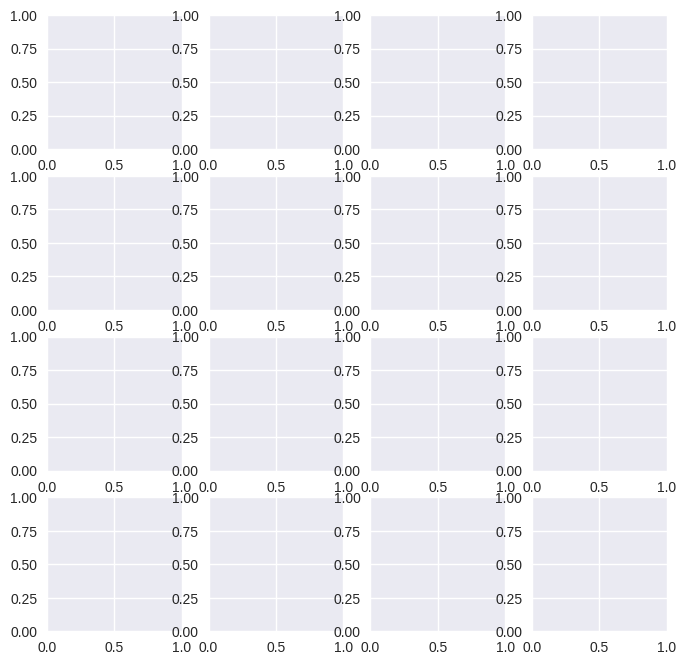

In [ ]:
# ── TASK 16 — Load MNIST, create DataLoaders, visualise samples ───────────────
#
# 1. Define transform: ToTensor() + Normalize(mean=(0.1307,), std=(0.3081,))
#    These are the official MNIST mean and std
#
# 2. Download train and test sets using torchvision.datasets.MNIST
#
# 3. Split train set into train (54,000) and validation (6,000)
#    Use torch.utils.data.random_split
#
# 4. Create DataLoaders:
#    train_loader: batch_size=64, shuffle=True
#    val_loader:   batch_size=256, shuffle=False
#    test_loader:  batch_size=256, shuffle=False
#
# 5. Print dataset sizes
#
# 6. Visualise 16 sample images in a 4×4 grid
#    Show the true label as the title of each subplot
#    Use cmap='gray'

# YOUR CODE HERE
transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.1307,), std=(0.3081,))
])   

train_full  = torchvision.datasets.MNIST(root='.', train=True, transform=transforms, download=True)
test_set    = torchvision.datasets.MNIST(root='.', train=False, transform=transforms, download=True)

train_set, val_set = torch.utils.data.random_split(train_full, [54000, 6000])
train_loader = DataLoader(train_set, batch_size = 64, shuffle = True)
val_loader = DataLoader(val_set, batch_size = 256, shuffle = False)
test_loader = DataLoader(test_set, batch_size = 256, shuffle = False)

print(f'Train set size : {len(train_set)}')
print(f'Validation set size : {len(val_set)}')
print(f'Test set size : {len(test_set)}')

fig, axes = plt.subplots(4,4, figsize = (8,8))
for i, ax in enumerate(axes.flatten()):
    img, label = train_full[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'Label: {label}')
    ax.axis('off')
plt.tight_layout()
plt.show()

# 📝 Why do we normalise with mean=0.1307 and std=0.3081?
# What would happen if we skipped normalisation?
# ...

In [ ]:
# ── TASK 17 — Build the MNIST MLP ────────────────────────────────────────────
# Architecture:
#   Flatten (28×28 → 784)
#   Linear(784, 256) → BatchNorm1d(256) → ReLU → Dropout(0.3)
#   Linear(256, 128) → BatchNorm1d(128) → ReLU → Dropout(0.2)
#   Linear(128, 10)  ← raw logits, no activation
#
# Notes:
#   - MNIST images arrive as shape (batch, 1, 28, 28)
#   - First operation in forward() must flatten to (batch, 784)
#     Use x.view(x.size(0), -1) or nn.Flatten()
#   - Do NOT add softmax — CrossEntropyLoss handles it
#
# After building:
#   - Move model to device
#   - Print architecture
#   - Print total parameter count

class MNISTClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        # YOUR CODE HERE
        pass

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # YOUR CODE HERE
        pass


mnist_model = MNISTClassifier().to(device)
print(mnist_model)
n_params = sum(p.numel() for p in mnist_model.parameters() if p.requires_grad)
print(f'\nTotal parameters: {n_params:,}')

# Sanity check
sample_batch, _ = next(iter(train_loader))
out = mnist_model(sample_batch.to(device))
print(f'Output shape: {out.shape}  (expected: [{sample_batch.size(0)}, 10])')

In [ ]:
# ── TASK 18 — Train the MNIST model for 10 epochs ────────────────────────────
# Use:
#   criterion = nn.CrossEntropyLoss()
#   optimizer = torch.optim.Adam(mnist_model.parameters(), lr=0.001)
#
# For each epoch:
#   - Call train_epoch() → get train_loss, train_acc
#   - Call evaluate()    → get val_loss,   val_acc
#   - Print: Epoch N/10 | Train Loss: X.XXXX | Val Loss: X.XXXX | Val Acc: XX.XX%
#
# Track all four metrics in lists for plotting

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mnist_model.parameters(), lr=0.001)

n_epochs      = 10
train_losses  = []
val_losses    = []
train_accs    = []
val_accs      = []

# YOUR CODE HERE


# 📝 Is the validation loss higher or lower than the training loss?
# What would it mean if val_loss started INCREASING while train_loss kept decreasing?
# ...

In [ ]:
# ── TASK 19 — Plot learning curves ───────────────────────────────────────────
# Create a 2×2 grid of subplots (figsize=(12, 8))
#   Top-left:     Training Loss
#   Top-right:    Validation Loss
#   Bottom-left:  Training Accuracy
#   Bottom-right: Validation Accuracy
#
# OR create 1×2 grid showing both losses on one plot and both accuracies on another
# (Your choice — whichever makes the comparison clearest)
#
# Add gridlines, axis labels, and a legend on each plot

epochs_range = range(1, n_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# YOUR CODE HERE


plt.suptitle('MNIST MLP — Training and Validation Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 📝 What do the curves tell you about overfitting?
# Did the model improve consistently across all 10 epochs?
# ...

In [ ]:
# ── TASK 20 — Final evaluation: classification report + confusion matrix ──────
#             + visualise correct and incorrect predictions
#
# Step 1: Run evaluate() on test_loader, print test loss and accuracy
#
# Step 2: Collect ALL predictions and true labels from the test set
#   (Loop over test_loader with model.eval() + torch.no_grad())
#
# Step 3: Print sklearn classification_report with target_names=['0','1',...,'9']
#
# Step 4: Plot confusion matrix as a heatmap (sns.heatmap, annot=True, fmt='d')
#
# Step 5: Visualise misclassified digits
#   Find indices where prediction != true label
#   Show 16 of them in a 4×4 grid
#   Title each subplot: "True: X  Pred: Y"

# Step 1 — test accuracy
test_loss, test_acc = evaluate(mnist_model, test_loader, criterion, device)
print(f'Test Loss: {test_loss:.4f}   Test Accuracy: {test_acc*100:.2f}%')

# Steps 2-4 — YOUR CODE HERE


# Step 5 — visualise errors
# YOUR CODE HERE


# 📝 Which digit pairs does the model confuse most often?
# (Look at the confusion matrix off-diagonal elements)
# Does that confusion make sense visually?
# ...

---
# 📝 Day 11 Summary

| Concept | Key Takeaway |
|---------|-------------|
| **Tensor** | PyTorch's n-dimensional array — can live on GPU, tracks gradients |
| **from_numpy** | Shares memory — modifying NumPy array changes the tensor |
| **requires_grad** | Tells PyTorch to track operations for automatic differentiation |
| **backward()** | Traverses the computational graph and computes all gradients |
| **zero_grad()** | Must be called before backward() — gradients accumulate otherwise |
| **nn.Module** | Base class for all models — automatic parameter tracking, device moving |
| **CrossEntropyLoss** | Takes raw logits — do NOT apply softmax first |
| **Adam** | Adaptive learning rates per parameter — better default than SGD |
| **model.train()** | Enables Dropout randomness and BatchNorm updates |
| **model.eval()** | Disables Dropout, freezes BatchNorm — always use for val/test |
| **torch.no_grad()** | Disables gradient tracking — faster and less memory during evaluation |
| **DataLoader** | Batching + shuffling — use mini-batch GD, not full-batch |

---
# 🏠 Homework

1. Experiment with three different learning rates: `[0.0001, 0.001, 0.01]`. Train for 5 epochs each. Plot all three loss curves on the same axes. Which diverges? Which is too slow?

2. Experiment with batch sizes `[32, 64, 256, 1024]`. For each, train for 5 epochs and record final val accuracy. How does batch size affect convergence speed and final accuracy?

3. Train the same architecture WITHOUT Dropout and WITHOUT BatchNorm. Compare the loss curves with and without regularisation. At which epoch does overfitting appear without regularisation?

4. Add a third hidden layer (64 units, ReLU) to the architecture. Does the extra depth help or hurt accuracy on MNIST? Why might very deep networks not always outperform shallower ones on simple datasets?

5. In your own words, explain what would happen to your training if you:
   - Forgot `optimizer.zero_grad()`
   - Forgot `model.eval()` during validation
   - Applied softmax before `CrossEntropyLoss`
   - Used `torch.from_numpy()` and then modified the original array